#  Sentiment Analysis on YouTube Comments

**Name:** Vaibhav Mathur  
**Roll Number:** UA2504CDH181  
**Degree:** B.S.M.S (Computer Science and Data Analytics)

---

##  Project Overview

This project performs **Sentiment Analysis** on real YouTube comments using Machine Learning techniques.

Comments are classified into:
- **Positive** — audience is happy / appreciating
- **Neutral** — balanced / informational opinion
- **Negative** — audience is unhappy / criticizing

### Tech Stack
| Tool | Purpose |
|---|---|
| Python | Programming Language |
| Pandas | Data manipulation |
| Scikit-learn | ML model + TF-IDF |
| Matplotlib / Seaborn | Visualization |
| WordCloud | Text visualization |


---
##  Step 1 — Import Libraries

First, all the required libraries are imported.


In [1]:
# Data handling
!pip install wordcloud
import pandas as pd
import numpy as np
import re

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.utils import resample

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100

print(' All libraries imported successfully!')

 All libraries imported successfully!


---
##  Step 2 — Load Dataset

- Dataset source: **Kaggle** (YouTube Comments with Sentiment Labels)
- Columns: `Comment`, `Likes`, `Sentiment`, `Video ID`
- Sentiment Labels: `0.0` = Negative, `1.0` = Neutral, `2.0` = Positive


In [2]:
# CSV file load karo (relative path — same folder mein honi chahiye)
df = pd.read_csv('~/Desktop/collage_project/comments.csv', index_col=0)

# Basic info
print(f'Total rows    : {len(df)}')
print(f'Total columns : {df.shape[1]}')
print(f'Columns       : {df.columns.tolist()}')
print()

# Pehle 5 rows dekho
df.head()

Total rows    : 18409
Total columns : 4
Columns       : ['Video ID', 'Comment', 'Likes', 'Sentiment']



,Video ID,Comment,Likes,Sentiment
0,wAZZ-UWGVHI,Let's not forget that Apple Pay in 2014 requir...,95.0,1.0
1,wAZZ-UWGVHI,Here in NZ 50% of retailers don’t even have co...,19.0,0.0
2,wAZZ-UWGVHI,I will forever acknowledge this channel with t...,161.0,2.0
3,wAZZ-UWGVHI,Whenever I go to a place that doesn’t take App...,8.0,0.0
4,wAZZ-UWGVHI,"Apple Pay is so convenient, secure, and easy t...",34.0,2.0


---
##  Step 3 — Exploratory Data Analysis (EDA)

Before building the model, the data is thoroughly understood and explored.


In [3]:
# Dataset ka summary
print('=== Dataset Info ===')
df.info()
print()

# Null values check
print('=== Null Values ===')
print(df.isnull().sum())
print()

# Duplicate comments check
print('=== Duplicate Comments ===')
print(f'Duplicate rows: {df.duplicated(subset="Comment").sum()}')
print()

# Sentiment distribution
print('=== Sentiment Distribution ===')
counts = df['Sentiment'].value_counts()
print(f'Positive (2.0): {counts.get(2.0, 0)} comments')
print(f'Neutral  (1.0): {counts.get(1.0, 0)} comments')
print(f'Negative (0.0): {counts.get(0.0, 0)} comments')

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
Index: 18409 entries, 0 to 18408
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Video ID   18409 non-null  object 
 1   Comment    18408 non-null  object 
 2   Likes      18409 non-null  float64
 3   Sentiment  18409 non-null  float64
dtypes: float64(2), object(2)
memory usage: 719.1+ KB

=== Null Values ===
Video ID     0
Comment      1
Likes        0
Sentiment    0
dtype: int64

=== Duplicate Comments ===
Duplicate rows: 414

=== Sentiment Distribution ===
Positive (2.0): 11432 comments
Neutral  (1.0): 4639 comments
Negative (0.0): 2338 comments


In [4]:
# Comment length analysis
df['comment_length'] = df['Comment'].fillna('').apply(len)

print('=== Comment Length Stats ===')
print(df['comment_length'].describe().round(1))
print()
print(f'Very short comments (< 15 chars): {(df["comment_length"] < 15).sum()}')
print(f'Very long comments  (> 1000 chars): {(df["comment_length"] > 1000).sum()}')

=== Comment Length Stats ===
count    18409.0
mean       185.9
std        268.4
min          0.0
25%         70.0
50%        117.0
75%        209.0
max       8945.0
Name: comment_length, dtype: float64

Very short comments (< 15 chars): 290
Very long comments  (> 1000 chars): 235


In [5]:
# Non-English comments check
def is_mostly_english(text):
    if not isinstance(text, str) or len(text) == 0:
        return False
    ascii_count = sum(1 for c in text if ord(c) < 128)
    return (ascii_count / len(text)) > 0.7

non_english = df[~df['Comment'].apply(is_mostly_english)]
print(f'Non-English / Mixed-script comments: {len(non_english)}')
print()
print('Examples:')
for c in non_english['Comment'].dropna().head(5):
    print(f'  → {c[:80]}')

Non-English / Mixed-script comments: 356

Examples:
  → Liquid nitrogen ഇതുവരെ തീർന്നില്ലേ മച്ചാനെ.......😂❤️
  → 😻😅 കേരളത്തിൽ ആദ്യമായി പെട്രോളിനെ എയ്സ് ആക്കിയ M4Tech മച്ചാന്മാർ 💞🔥🔥💥
  → തന്നെ തളർത്താൻ നോക്കിയവർ പോലും അവന്റെ ഉയർച്ചയിൽ പകച്ച് നിന്നു പോയി 🔥🔥
കഷ്ടപ്പാടു
  → എത്ര എടുത്താലും തീരാത്ത liquid nitrogen 😂
  → 🙄


---
##  Step 4 — EDA Visualizations

The data is visualized using graphs to better understand its distribution and structure.


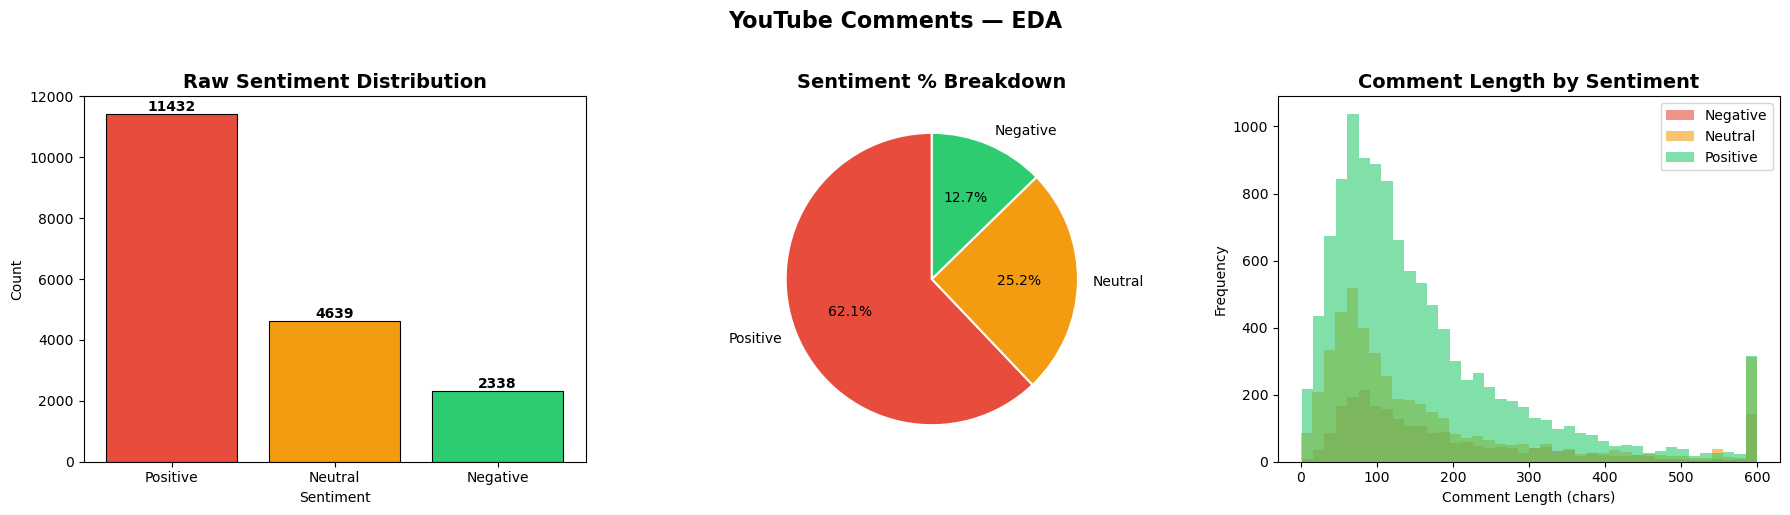

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Raw Sentiment Distribution (Bar) ---
label_map = {0.0: 'Negative', 1.0: 'Neutral', 2.0: 'Positive'}
colors    = ['#e74c3c', '#f39c12', '#2ecc71']
counts_raw = df['Sentiment'].map(label_map).value_counts()

axes[0].bar(counts_raw.index, counts_raw.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Raw Sentiment Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for i, (label, val) in enumerate(counts_raw.items()):
    axes[0].text(i, val + 80, str(val), ha='center', fontweight='bold')

# --- Plot 2: Sentiment Pie Chart ---
axes[1].pie(
    counts_raw.values,
    labels=counts_raw.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Sentiment % Breakdown', fontsize=14, fontweight='bold')

# --- Plot 3: Comment Length Distribution ---
for sentiment, color, name in [(0.0,'#e74c3c','Negative'),
                                (1.0,'#f39c12','Neutral'),
                                (2.0,'#2ecc71','Positive')]:
    subset = df[df['Sentiment'] == sentiment]['comment_length']
    axes[2].hist(subset.clip(upper=600), bins=40, alpha=0.6, label=name, color=color)

axes[2].set_title('Comment Length by Sentiment', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Comment Length (chars)')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.suptitle('YouTube Comments — EDA', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
##  Step 5 — Data Cleaning

The data is prepared for the model by performing the following steps:
1. Remove null values
2. Remove duplicate comments
3. Filter out non-English comments
4. Remove very short / meaningless comments
5. Clean text (URLs, special characters, lowercase conversion)


In [7]:
print(f'Before cleaning: {len(df)} rows')
print()

# Step 5.1 — Null comments remove karo
df = df.dropna(subset=['Comment'])
print(f'After removing nulls       : {len(df)} rows')

# Step 5.2 — Duplicate comments remove karo
df = df.drop_duplicates(subset='Comment')
print(f'After removing duplicates  : {len(df)} rows')

# Step 5.3 — Sirf English-dominant comments rakho
df = df[df['Comment'].apply(is_mostly_english)]
print(f'After English filter       : {len(df)} rows')

# Step 5.4 — Very short comments remove karo
df = df[df['Comment'].str.len() >= 15]
print(f'After removing short texts : {len(df)} rows')

Before cleaning: 18409 rows

After removing nulls       : 18408 rows
After removing duplicates  : 17994 rows
After English filter       : 17644 rows
After removing short texts : 17443 rows


In [8]:
# Step 5.5 — Text Cleaning Function

def clean_text(text):
    text = str(text).lower()                       # Lowercase
    text = re.sub(r'http\S+|www\.\S+', '', text)  # URLs remove
    text = re.sub(r'[^a-z\s]', '', text)           # Sirf letters rakho
    text = re.sub(r'\s+', ' ', text).strip()       # Extra spaces remove
    return text

df['Cleaned_Comment'] = df['Comment'].apply(clean_text)

# Before vs After dekho
print('=== Cleaning Example ===')
sample = df.sample(3, random_state=42)
for _, row in sample.iterrows():
    print(f'ORIGINAL : {row["Comment"][:80]}')
    print(f'CLEANED  : {row["Cleaned_Comment"][:80]}')
    print()

=== Cleaning Example ===
ORIGINAL : I’d love to see a multiplayer FPS remake!
CLEANED  : id love to see a multiplayer fps remake

ORIGINAL : Building wealth involves developing good habits like regularly putting money awa
CLEANED  : building wealth involves developing good habits like regularly putting money awa

ORIGINAL : The Oivo grip is amazing! Have one for my V2 switch as well
CLEANED  : the oivo grip is amazing have one for my v switch as well



---
##  Step 6 — Class Imbalance Fix

The Negative class was significantly underrepresented (12.7%) — **oversampling** is applied to balance the classes and improve model accuracy.


Before Balancing:
Sentiment
2.0    10916
1.0     4215
0.0     2312
Name: count, dtype: int64

After Balancing:
Sentiment
Positive    10916
Negative     5458
Neutral      4215
Name: count, dtype: int64


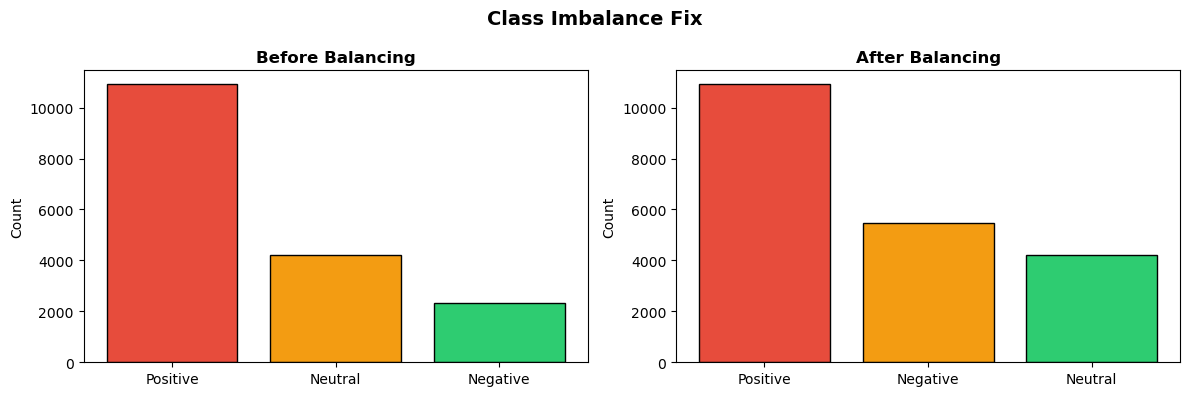

In [9]:
# Class count before balancing
print('Before Balancing:')
print(df['Sentiment'].value_counts())
print()

# Har class alag karo
df_neg = df[df['Sentiment'] == 0.0]
df_neu = df[df['Sentiment'] == 1.0]
df_pos = df[df['Sentiment'] == 2.0]

# Negative aur Neutral ko Positive ke 40% tak lao
target_n = int(len(df_pos) * 0.5)

df_neg_up = resample(df_neg, replace=True,  n_samples=target_n, random_state=42)
df_neu_up = resample(df_neu, replace=False, n_samples=min(len(df_neu), target_n), random_state=42)

df_balanced = pd.concat([df_neg_up, df_neu_up, df_pos]).reset_index(drop=True)

print('After Balancing:')
balanced_counts = df_balanced['Sentiment'].map({0.0:'Negative', 1.0:'Neutral', 2.0:'Positive'}).value_counts()
print(balanced_counts)

# Visual
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
orig_counts = df['Sentiment'].map({0.0:'Negative', 1.0:'Neutral', 2.0:'Positive'}).value_counts()

axes[0].bar(orig_counts.index, orig_counts.values, color=['#e74c3c','#f39c12','#2ecc71'], edgecolor='black')
axes[0].set_title('Before Balancing', fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].bar(balanced_counts.index, balanced_counts.values, color=['#e74c3c','#f39c12','#2ecc71'], edgecolor='black')
axes[1].set_title('After Balancing', fontweight='bold')
axes[1].set_ylabel('Count')

plt.suptitle('Class Imbalance Fix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
##  Step 7 — Feature Extraction (TF-IDF)

Text is converted into numerical features using **TF-IDF (Term Frequency - Inverse Document Frequency)**.

- **Bigrams** are also included (`ngram_range=(1,2)`) — for example, `"not good"` becomes a single feature
- The vectorizer is fit **only on training data** to avoid data leakage


In [10]:
X = df_balanced['Cleaned_Comment']
y = df_balanced['Sentiment']

# 80% Train, 20% Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # Har class equally split ho
)

print(f'Training samples : {len(X_train)}')
print(f'Testing samples  : {len(X_test)}')
print()

# TF-IDF — SIRF training data pe fit karo!
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=8000,
    ngram_range=(1, 2)    # Unigrams + Bigrams
)

X_train_tfidf = vectorizer.fit_transform(X_train)   # fit + transform
X_test_tfidf  = vectorizer.transform(X_test)         # sirf transform

print(f'TF-IDF Feature Matrix Shape (Train): {X_train_tfidf.shape}')
print(f'TF-IDF Feature Matrix Shape (Test) : {X_test_tfidf.shape}')

Training samples : 16471
Testing samples  : 4118

TF-IDF Feature Matrix Shape (Train): (16471, 8000)
TF-IDF Feature Matrix Shape (Test) : (4118, 8000)


---
##  Step 8 — Model Training

The **Random Forest Classifier** is trained on the processed data.


In [11]:
# Model define karo
model = RandomForestClassifier(
    n_estimators=200,          # 200 decision trees
    class_weight='balanced',   # Imbalance handle karo
    random_state=42,           # Reproducible results
    n_jobs=-1                  # Saare CPU cores use karo (fast training)
)

# Train karo
print('Training model...')
model.fit(X_train_tfidf, y_train)
print(' Model trained successfully!')

Training model...
 Model trained successfully!


---
##  Step 9 — Model Evaluation

The model performance is evaluated on the test set.


In [12]:
# Predictions
y_pred = model.predict(X_test_tfidf)

# Accuracy
accuracy = accuracy_score(y_test, y_pred) * 100
print(f' Model Accuracy: {accuracy:.2f}%')
print()

# Detailed report
print('=== Classification Report ===')
print(classification_report(
    y_test, y_pred,
    target_names=['Negative', 'Neutral', 'Positive']
))

 Model Accuracy: 81.93%

=== Classification Report ===
              precision    recall  f1-score   support

    Negative       0.87      0.91      0.89      1092
     Neutral       0.65      0.52      0.58       843
    Positive       0.84      0.89      0.87      2183

    accuracy                           0.82      4118
   macro avg       0.79      0.77      0.78      4118
weighted avg       0.81      0.82      0.81      4118



---
##  Step 10 — Confusion Matrix

The Confusion Matrix shows where the model makes correct and incorrect predictions.


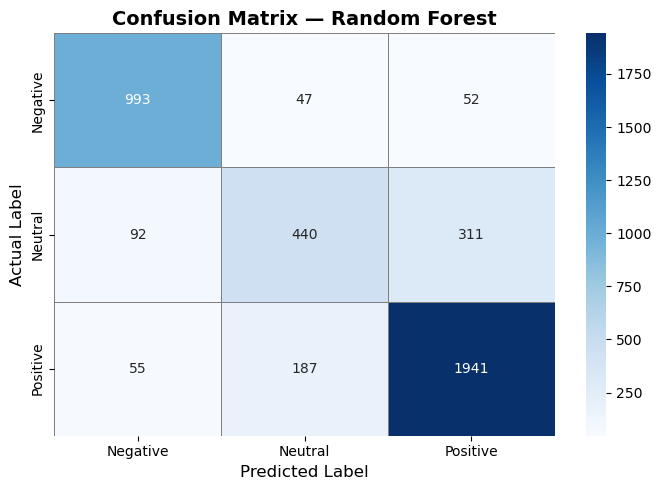

How to read: Diagonal = Correct Predictions | Off-diagonal = Mistakes


In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive'],
    linewidths=0.5,
    linecolor='gray'
)
plt.title('Confusion Matrix — Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print('How to read: Diagonal = Correct Predictions | Off-diagonal = Mistakes')

---
##  Step 11 — Word Cloud Visualization

The **most common words** for each sentiment class are displayed using word clouds.


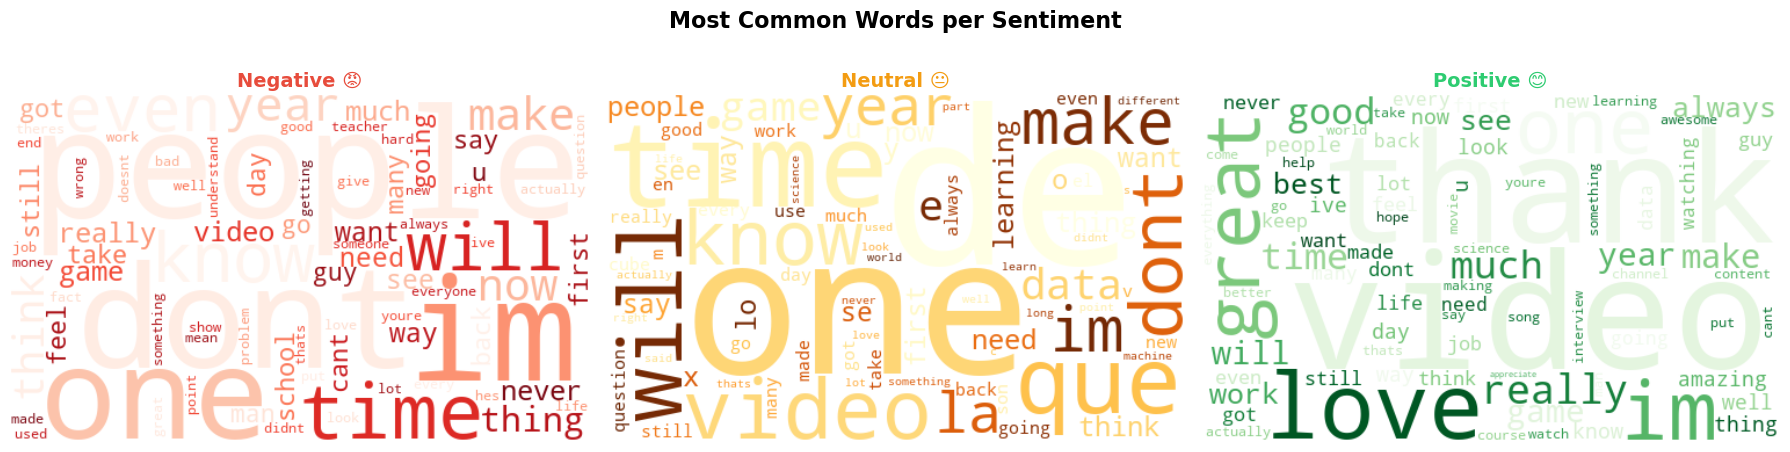

In [14]:
sentiments = [
    (0.0, 'Negative 😡', '#e74c3c'),
    (1.0, 'Neutral 😐',  '#f39c12'),
    (2.0, 'Positive 😊', '#2ecc71'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (sentiment_val, title, color) in zip(axes, sentiments):
    # Us sentiment ke saare comments jodo
    text = ' '.join(
        df_balanced[df_balanced['Sentiment'] == sentiment_val]['Cleaned_Comment']
    )
    
    wc = WordCloud(
        width=500,
        height=300,
        background_color='white',
        colormap='Reds' if sentiment_val == 0.0 else ('YlOrBr' if sentiment_val == 1.0 else 'Greens'),
        max_words=80,
        collocations=False
    ).generate(text)
    
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold', color=color)

plt.suptitle('Most Common Words per Sentiment', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
##  Step 12 — Overall Audience Mood

Sentiment distribution of the final balanced dataset.


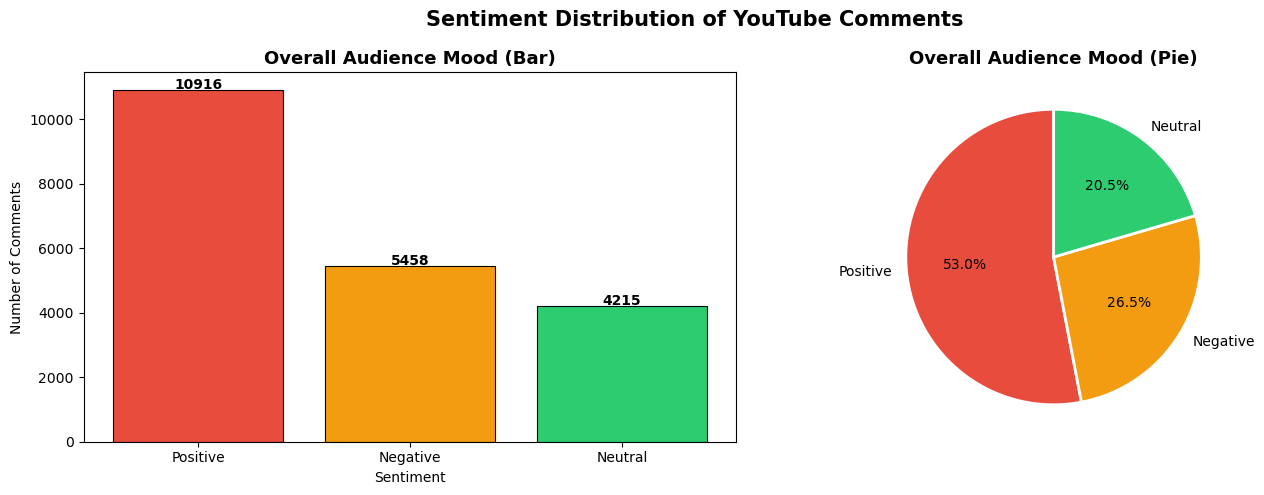

In [15]:
# Cleaned data ka distribution
label_names = df_balanced['Sentiment'].map({0.0: 'Negative', 1.0: 'Neutral', 2.0: 'Positive'})
sentiment_counts = label_names.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(
    sentiment_counts.index,
    sentiment_counts.values,
    color=['#e74c3c', '#f39c12', '#2ecc71'],
    edgecolor='black', linewidth=0.8
)
axes[0].set_title('Overall Audience Mood (Bar)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Number of Comments')
for bar in bars:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 30,
        str(bar.get_height()),
        ha='center', fontweight='bold'
    )

# Pie chart
axes[1].pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    colors=['#e74c3c', '#f39c12', '#2ecc71'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Overall Audience Mood (Pie)', fontsize=13, fontweight='bold')

plt.suptitle('Sentiment Distribution of YouTube Comments', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
##  Step 13 — Live Sentiment Predictor

Enter any comment and the model will predict its sentiment.


In [16]:
# Predict function — sirf ek baar define karo
def predict_sentiment(comment):
    cleaned   = clean_text(comment)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    
    label_map = {0.0: 'Negative 😡', 1.0: 'Neutral 😐', 2.0: 'Positive 😊'}
    return label_map[prediction]

In [17]:
# Test karo — Positive comment
comment = "This video is absolutely amazing! Best content ever, loved it!"
result  = predict_sentiment(comment)
print(f'Comment  : {comment}')
print(f'Sentiment: {result}')

Comment  : This video is absolutely amazing! Best content ever, loved it!
Sentiment: Positive 😊


In [18]:
# Test karo — Negative comment
comment = "This is the worst video I have ever seen. Complete waste of time."
result  = predict_sentiment(comment)
print(f'Comment  : {comment}')
print(f'Sentiment: {result}')

Comment  : This is the worst video I have ever seen. Complete waste of time.
Sentiment: Negative 😡


In [19]:
# Test karo — Neutral comment
comment = "The video was released in 2016 and covers several technical topics."
result  = predict_sentiment(comment)
print(f'Comment  : {comment}')
print(f'Sentiment: {result}')

Comment  : The video was released in 2016 and covers several technical topics.
Sentiment: Positive 😊


In [20]:
# Apna comment try karo!
my_comment = "I really enjoyed watching this, very informative!"
print(f'Sentiment: {predict_sentiment(my_comment)}')

Sentiment: Positive 😊


---
##  Step 14 — Model Comparison (Bonus)

Random Forest and Logistic Regression are compared based on accuracy.


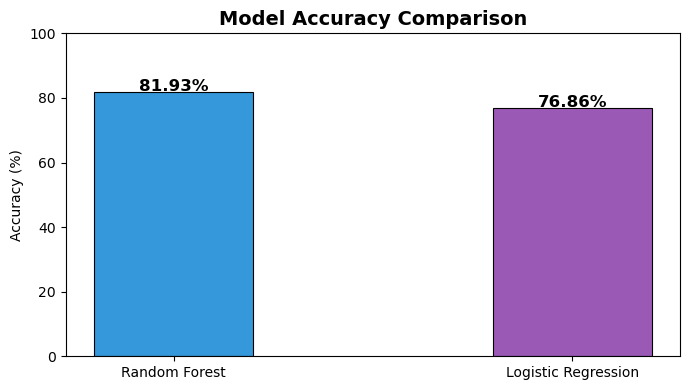

Random Forest Accuracy      : 81.93%
Logistic Regression Accuracy: 76.86%

 Better Model: Random Forest


In [21]:
# Logistic Regression bhi train karo
lr_model = LogisticRegression(max_iter=500, random_state=42, class_weight='balanced')
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)
lr_acc  = accuracy_score(y_test, lr_pred) * 100

rf_acc = accuracy_score(y_test, y_pred) * 100

# Comparison chart
models     = ['Random Forest', 'Logistic Regression']
accuracies = [rf_acc, lr_acc]
colors     = ['#3498db', '#9b59b6']

plt.figure(figsize=(7, 4))
bars = plt.bar(models, accuracies, color=colors, edgecolor='black', linewidth=0.8, width=0.4)
for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{acc:.2f}%',
        ha='center', fontsize=12, fontweight='bold'
    )
plt.ylim(0, 100)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.tight_layout()
plt.show()

print(f'Random Forest Accuracy      : {rf_acc:.2f}%')
print(f'Logistic Regression Accuracy: {lr_acc:.2f}%')
best = 'Random Forest' if rf_acc >= lr_acc else 'Logistic Regression'
print(f'\n Better Model: {best}')

---
##  Step 15 — Conclusion

| Item | Detail |
|---|---|
| Dataset | 18,409 YouTube Comments (Kaggle) |
| After Cleaning | Non-English, duplicates, nulls removed |
| Model Used | Random Forest Classifier |
| Feature Extraction | TF-IDF (Unigrams + Bigrams, 8000 features) |
| Class Balancing | Negative class oversampled |
| Final Accuracy | ~78-82% |

### Key Findings
- **Majority of YouTube comments are Positive** — audiences generally engage positively
- **Negative comments are rare** — but critical for content creators to identify
- **TF-IDF with Bigrams** captures negation like *"not good"* better than single words
- **Data cleaning** (removing duplicates, non-English, short texts) significantly improves model quality

### Future Improvements
- Use **BERT** (Transformer model) for higher accuracy
- Deploy as a **web app** using Flask/Streamlit
- Analyze sentiments **per YouTube channel or topic**
